# Annotation-Free Face + Jersey Segmentation Pipeline

This notebook implements an annotation-free preprocessing pipeline for CycleGAN preparation.

- Input: all images under `dataset/` (no COCO annotation dependency)
- Segmentation: pretrained inference only
- Output: standardized `256x256` exports
- Includes: input validation, robust error handling, and unit tests

## 1) Set Up Workspace and Imports
Import dependencies, enforce reproducibility defaults, and print runtime information.

In [41]:
import os
import sys
import json
import random
import platform
import traceback
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
from PIL import Image

try:
    import cv2
except Exception as exc:
    raise RuntimeError("OpenCV is required. Install with: pip install opencv-python") from exc

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError("Matplotlib is required. Install with: pip install matplotlib") from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-10-10.0.19045-SP0
OpenCV: 4.13.0
NumPy: 2.4.3


## 2) Define Project Structure and Configuration
Centralized configuration for paths, thresholds, model behavior, and export settings.

In [42]:
@dataclass
class PipelineConfig:
    dataset_dir: Path = Path("dataset")
    output_dir: Path = Path("outputs")
    image_size: int = 256
    supported_exts: Tuple[str, ...] = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    person_conf_threshold: float = 0.25
    keep_if_any_region: bool = True
    max_images: Optional[int] = None
    random_sample: bool = False

    save_face_mask: bool = True
    save_jersey_mask: bool = True
    save_combined_mask: bool = True
    save_masked_rgb: bool = True

    background_color: Tuple[int, int, int] = (0, 0, 0)


def validate_config(config: PipelineConfig) -> None:
    if not config.dataset_dir.exists() or not config.dataset_dir.is_dir():
        raise ValueError(f"Dataset directory not found: {config.dataset_dir}")
    if config.image_size <= 0:
        raise ValueError("image_size must be > 0")
    if not (0.0 <= config.person_conf_threshold <= 1.0):
        raise ValueError("person_conf_threshold must be in [0, 1]")


config = PipelineConfig()
validate_config(config)
print(config)

PipelineConfig(dataset_dir=WindowsPath('dataset'), output_dir=WindowsPath('outputs'), image_size=256, supported_exts=('.jpg', '.jpeg', '.png', '.bmp', '.webp'), person_conf_threshold=0.25, keep_if_any_region=True, max_images=None, random_sample=False, save_face_mask=True, save_jersey_mask=True, save_combined_mask=True, save_masked_rgb=True, background_color=(0, 0, 0))


## 3) Implement Core Functions
First working implementation with modular functions and type hints.

In [43]:
def list_images(dataset_dir: Path, exts: Tuple[str, ...]) -> List[Path]:
    """Return all image files in dataset_dir recursively, sorted for deterministic processing."""
    return sorted([p for p in dataset_dir.rglob("*") if p.suffix.lower() in exts and p.is_file()])


def ensure_dirs(output_dir: Path) -> Dict[str, Path]:
    """Create and return all export directories."""
    paths = {
        "masked_rgb": output_dir / "masked_rgb",
        "face_mask": output_dir / "face_mask",
        "jersey_mask": output_dir / "jersey_mask",
        "combined_mask": output_dir / "combined_mask",
    }
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    return paths


def read_rgb(path: Path) -> np.ndarray:
    """Read image as RGB uint8 array."""
    with Image.open(path) as img:
        return np.array(img.convert("RGB"), dtype=np.uint8)


def resize_with_padding_rgb(img_rgb: np.ndarray, size: int, bg: Tuple[int, int, int]) -> np.ndarray:
    """Resize to square with preserved aspect ratio and padding."""
    h, w = img_rgb.shape[:2]
    if h == 0 or w == 0:
        raise ValueError("Invalid image with zero dimension")
    scale = min(size / w, size / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(img_rgb, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((size, size, 3), np.array(bg, dtype=np.uint8), dtype=np.uint8)
    y0 = (size - nh) // 2
    x0 = (size - nw) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = resized
    return canvas


def resize_with_padding_mask(mask: np.ndarray, size: int) -> np.ndarray:
    """Resize binary mask to square with padding."""
    h, w = mask.shape[:2]
    if h == 0 or w == 0:
        raise ValueError("Invalid mask with zero dimension")
    scale = min(size / w, size / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(mask.astype(np.uint8), (nw, nh), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((size, size), dtype=np.uint8)
    y0 = (size - nh) // 2
    x0 = (size - nw) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = resized
    return canvas


def ellipse_face_mask(shape_hw: Tuple[int, int], bbox_xyxy: Tuple[int, int, int, int]) -> np.ndarray:
    """Create a soft-geometry face mask from a face bounding box."""
    h, w = shape_hw
    x1, y1, x2, y2 = bbox_xyxy
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w - 1, x2), min(h - 1, y2)
    mask = np.zeros((h, w), dtype=np.uint8)
    if x2 <= x1 or y2 <= y1:
        return mask
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    rx = max(1, (x2 - x1) // 2)
    ry = max(1, (y2 - y1) // 2)
    cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 255, -1)
    return mask


def clean_binary_mask(mask: np.ndarray, min_area: int = 150, kernel_size: int = 3) -> np.ndarray:
    """Apply morphology and remove tiny connected components."""
    mask_u8 = (mask > 0).astype(np.uint8) * 255
    kernel_size = max(1, int(kernel_size))
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    out = np.zeros_like(mask_u8)
    for label_idx in range(1, num_labels):
        area = stats[label_idx, cv2.CC_STAT_AREA]
        if area >= min_area:
            out[labels == label_idx] = 255
    return out


class AnnotationFreeSegmenter:
    """Annotation-free inference helper using pretrained models where available.

    Preferred stack:
    - Person segmentation: Ultralytics YOLOv8 segmentation (`yolov8n-seg.pt`) if installed.
    - Face detection: MediaPipe face detection if installed, else OpenCV Haar cascade.
    - Jersey mask: derived from person mask via upper-body heuristic.
    """

    def __init__(self, person_conf_threshold: float = 0.25):
        self.person_conf_threshold = person_conf_threshold
        self.yolo = None
        self.mp_face_detectors = []
        self.haar = None

        try:
            from ultralytics import YOLO
            self.yolo = YOLO("yolov8n-seg.pt")
        except Exception:
            self.yolo = None

        try:
            import mediapipe as mp
            self.mp_face_detectors = [
                mp.solutions.face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.25),
                mp.solutions.face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.25),
            ]
        except Exception:
            self.mp_face_detectors = []

        try:
            haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            self.haar = cv2.CascadeClassifier(haar_path)
            if self.haar.empty():
                self.haar = None
        except Exception:
            self.haar = None

    @staticmethod
    def _clip_box(box: Tuple[int, int, int, int], h: int, w: int) -> Tuple[int, int, int, int]:
        x1, y1, x2, y2 = box
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)
        return x1, y1, x2, y2

    @staticmethod
    def _box_iou(a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]) -> float:
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        ix1, iy1 = max(ax1, bx1), max(ay1, by1)
        ix2, iy2 = min(ax2, bx2), min(ay2, by2)
        if ix2 < ix1 or iy2 < iy1:
            return 0.0
        inter = float((ix2 - ix1 + 1) * (iy2 - iy1 + 1))
        area_a = float(max(0, ax2 - ax1 + 1) * max(0, ay2 - ay1 + 1))
        area_b = float(max(0, bx2 - bx1 + 1) * max(0, by2 - by1 + 1))
        denom = area_a + area_b - inter
        if denom <= 0.0:
            return 0.0
        return inter / denom

    @staticmethod
    def _nms_boxes(candidates: List[Tuple[Tuple[int, int, int, int], float]], iou_thresh: float = 0.35) -> List[Tuple[int, int, int, int]]:
        if not candidates:
            return []
        ranked = sorted(candidates, key=lambda item: item[1], reverse=True)
        kept: List[Tuple[int, int, int, int]] = []
        for box, _score in ranked:
            if all(AnnotationFreeSegmenter._box_iou(box, kb) < iou_thresh for kb in kept):
                kept.append(box)
        return kept

    @staticmethod
    def _dominant_person_labels(person_stats: np.ndarray, img_h: int, min_area: int = 400, top_k: int = 2) -> List[int]:
        """Select top foreground person components likely to be main players."""
        if person_stats is None or len(person_stats) <= 1:
            return []

        scored: List[Tuple[int, int]] = []
        for label in range(1, len(person_stats)):
            area = int(person_stats[label, cv2.CC_STAT_AREA])
            comp_h = int(person_stats[label, cv2.CC_STAT_HEIGHT])
            comp_w = int(person_stats[label, cv2.CC_STAT_WIDTH])
            if area < min_area:
                continue
            if comp_h < int(0.20 * img_h):
                continue
            if (comp_w / max(1, comp_h)) > 1.6:
                continue
            scored.append((label, area))

        if not scored:
            areas = [int(person_stats[i, cv2.CC_STAT_AREA]) for i in range(1, len(person_stats))]
            if not areas:
                return []
            return [1 + int(np.argmax(areas))]

        scored.sort(key=lambda item: item[1], reverse=True)
        return [label for label, _ in scored[: max(1, top_k)]]

    @staticmethod
    def _head_mask_from_person(person_mask: np.ndarray, keep_labels: Optional[List[int]] = None) -> np.ndarray:
        """Fallback head approximation from the upper part of each person component."""
        h, w = person_mask.shape[:2]
        person_u8 = (person_mask > 0).astype(np.uint8)
        out = np.zeros((h, w), dtype=np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(person_u8, connectivity=8)
        keep_set = set(keep_labels) if keep_labels is not None else None

        for label_idx in range(1, num_labels):
            if keep_set is not None and label_idx not in keep_set:
                continue
            area = int(stats[label_idx, cv2.CC_STAT_AREA])
            if area < 250:
                continue
            x = int(stats[label_idx, cv2.CC_STAT_LEFT])
            y = int(stats[label_idx, cv2.CC_STAT_TOP])
            bw = int(stats[label_idx, cv2.CC_STAT_WIDTH])
            bh = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
            if bw < 8 or bh < 16:
                continue
            if (bw / max(1, bh)) > 0.95:
                continue

            head_h = max(6, int(0.20 * bh))
            head_w = max(8, min(int(0.44 * bw), int(0.34 * bh)))
            cx = x + bw // 2
            hx1 = max(0, cx - head_w // 2)
            hx2 = min(w - 1, cx + head_w // 2)
            hy1 = y
            hy2 = min(h - 1, y + head_h)
            if hx2 <= hx1 or hy2 <= hy1:
                continue

            head = ellipse_face_mask((h, w), (hx1, hy1, hx2, hy2))
            out = np.maximum(out, head)

        return clean_binary_mask(out, min_area=60)

    @staticmethod
    def _filter_face_component_sizes(mask: np.ndarray, min_area: int = 60, max_area_ratio: float = 0.04) -> np.ndarray:
        h, w = mask.shape[:2]
        max_area = int(max_area_ratio * h * w)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
        out = np.zeros_like(mask, dtype=np.uint8)
        for label_idx in range(1, num_labels):
            area = int(stats[label_idx, cv2.CC_STAT_AREA])
            if min_area <= area <= max_area:
                out[labels == label_idx] = 255
        return out

    def person_mask(self, rgb: np.ndarray) -> Tuple[np.ndarray, float]:
        """Return binary person mask and confidence score."""
        h, w = rgb.shape[:2]
        if self.yolo is None:
            return np.zeros((h, w), dtype=np.uint8), 0.0

        results = self.yolo.predict(rgb, verbose=False, conf=self.person_conf_threshold)
        if not results:
            return np.zeros((h, w), dtype=np.uint8), 0.0

        result = results[0]
        if result.masks is None or result.boxes is None:
            return np.zeros((h, w), dtype=np.uint8), 0.0

        mask_out = np.zeros((h, w), dtype=np.uint8)
        best_conf = 0.0

        boxes = result.boxes
        classes = boxes.cls.cpu().numpy() if boxes.cls is not None else np.array([])
        confs = boxes.conf.cpu().numpy() if boxes.conf is not None else np.array([])
        masks = result.masks.data.cpu().numpy() if result.masks is not None else np.array([])

        for idx in range(min(len(classes), len(confs), len(masks))):
            cls_id = int(classes[idx])
            conf = float(confs[idx])
            if cls_id != 0:
                continue
            resized = cv2.resize(masks[idx].astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
            current = (resized > 0.5).astype(np.uint8) * 255
            mask_out = np.maximum(mask_out, current)
            best_conf = max(best_conf, conf)

        return clean_binary_mask(mask_out), best_conf

    def _collect_face_candidates(self, rgb: np.ndarray) -> List[Tuple[Tuple[int, int, int, int], float]]:
        h, w = rgb.shape[:2]
        candidates: List[Tuple[Tuple[int, int, int, int], float]] = []

        for detector in self.mp_face_detectors:
            try:
                result = detector.process(rgb)
                if result.detections:
                    for det in result.detections:
                        bb = det.location_data.relative_bounding_box
                        x = int(bb.xmin * w)
                        y = int(bb.ymin * h)
                        bw = int(bb.width * w)
                        bh = int(bb.height * h)
                        score = float(det.score[0]) if hasattr(det, "score") and det.score else 0.5
                        candidates.append(((x, y, x + bw, y + bh), score))
            except Exception:
                pass

        if self.haar is not None:
            gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            faces = self.haar.detectMultiScale(gray, scaleFactor=1.08, minNeighbors=4, minSize=(16, 16))
            for (x, y, bw, bh) in faces:
                candidates.append(((x, y, x + bw, y + bh), 0.35))

        return candidates

    def face_mask(self, rgb: np.ndarray, person_mask: Optional[np.ndarray] = None) -> np.ndarray:
        """Return binary face mask by assigning best detected face to each dominant person component."""
        h, w = rgb.shape[:2]

        if person_mask is None or person_mask.shape[:2] != (h, w) or person_mask.sum() == 0:
            return np.zeros((h, w), dtype=np.uint8)

        person_u8 = (person_mask > 0).astype(np.uint8)
        _, person_labels, person_stats, _ = cv2.connectedComponentsWithStats(person_u8, connectivity=8)
        dominant_labels = self._dominant_person_labels(person_stats, img_h=h, top_k=2)
        if not dominant_labels:
            return np.zeros((h, w), dtype=np.uint8)

        person_dilated = cv2.dilate(np.isin(person_labels, dominant_labels).astype(np.uint8), np.ones((9, 9), np.uint8), iterations=1)

        candidate_boxes = self._nms_boxes(self._collect_face_candidates(rgb), iou_thresh=0.35)
        out = np.zeros((h, w), dtype=np.uint8)

        for label in dominant_labels:
            comp_x = int(person_stats[label, cv2.CC_STAT_LEFT])
            comp_y = int(person_stats[label, cv2.CC_STAT_TOP])
            comp_w = int(person_stats[label, cv2.CC_STAT_WIDTH])
            comp_h = int(person_stats[label, cv2.CC_STAT_HEIGHT])
            comp_area = int(person_stats[label, cv2.CC_STAT_AREA])

            comp_center_x = comp_x + comp_w // 2
            target_y = comp_y + int(0.20 * comp_h)

            best_box = None
            best_score = float("inf")

            for raw_box in candidate_boxes:
                x1, y1, x2, y2 = self._clip_box(raw_box, h, w)
                bw = x2 - x1 + 1
                bh = y2 - y1 + 1
                if bw < 8 or bh < 8:
                    continue

                aspect = bw / max(1, bh)
                if aspect < 0.55 or aspect > 1.9:
                    continue

                area = bw * bh
                if area < max(24, int(0.0020 * comp_area)) or area > int(0.15 * comp_area):
                    continue

                cx = (x1 + x2) // 2
                cy = (y1 + y2) // 2
                if cy > comp_y + int(0.55 * comp_h):
                    continue
                if cx < comp_x - int(0.12 * comp_w) or cx > comp_x + int(1.12 * comp_w):
                    continue
                if person_dilated[cy, cx] == 0:
                    continue

                score = abs(cx - comp_center_x) + 0.7 * abs(cy - target_y)
                if score < best_score:
                    best_score = score
                    best_box = (x1, y1, x2, y2)

            if best_box is not None:
                x1, y1, x2, y2 = best_box
                x_pad = int(0.06 * (x2 - x1 + 1))
                y_pad = int(0.05 * (y2 - y1 + 1))
                face = ellipse_face_mask((h, w), (x1 + x_pad, y1 + y_pad, x2 - x_pad, y2 - y_pad))
            else:
                cx = comp_center_x
                fw = max(8, min(int(0.42 * comp_w), int(0.34 * comp_h)))
                fh = max(10, int(0.20 * comp_h))
                face = ellipse_face_mask((h, w), (cx - fw // 2, comp_y, cx + fw // 2, comp_y + fh))

            comp_mask = (person_labels == label).astype(np.uint8) * 255
            face = cv2.bitwise_and(face, cv2.dilate(comp_mask, np.ones((5, 5), np.uint8), iterations=1))
            out = np.maximum(out, face)

        out = clean_binary_mask(out, min_area=60, kernel_size=3)
        out = self._filter_face_component_sizes(out, min_area=60, max_area_ratio=0.04)

        if out.sum() > 0:
            return out

        return self._head_mask_from_person(person_mask, keep_labels=dominant_labels)

    @staticmethod
    def jersey_mask_from_person_and_face(person_mask: np.ndarray, face_mask: np.ndarray) -> np.ndarray:
        """Approximate jersey region from person mask using upper-body heuristic excluding face."""
        person = (person_mask > 0).astype(np.uint8)
        face = (face_mask > 0).astype(np.uint8)
        if person.sum() == 0:
            return np.zeros_like(person_mask, dtype=np.uint8)

        ys, xs = np.where(person > 0)
        y_min, y_max = int(ys.min()), int(ys.max())
        x_min, x_max = int(xs.min()), int(xs.max())

        height = y_max - y_min + 1
        y_top = y_min + int(0.20 * height)
        y_bottom = y_min + int(0.72 * height)

        torso = np.zeros_like(person, dtype=np.uint8)
        torso[y_top:y_bottom, x_min:x_max + 1] = 1

        jersey = ((person == 1) & (torso == 1) & (face == 0)).astype(np.uint8) * 255
        return clean_binary_mask(jersey, min_area=120)


def compose_masked_rgb(rgb: np.ndarray, combined_mask: np.ndarray, bg: Tuple[int, int, int]) -> np.ndarray:
    """Apply binary mask to RGB image with fixed background color."""
    out = np.full_like(rgb, np.array(bg, dtype=np.uint8))
    m = combined_mask > 0
    out[m] = rgb[m]
    return out

## 4) Add Input Validation and Error Handling
Guard clauses and structured handling for invalid images or inference failures.

In [44]:
def validate_rgb_image(rgb: np.ndarray) -> None:
    """Ensure valid RGB image tensor."""
    if not isinstance(rgb, np.ndarray):
        raise TypeError("Image must be numpy array")
    if rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError(f"Expected HxWx3 image, got shape={rgb.shape}")
    if rgb.dtype != np.uint8:
        raise ValueError(f"Expected uint8 image, got dtype={rgb.dtype}")


def process_one_image(path: Path, segmenter: AnnotationFreeSegmenter, cfg: PipelineConfig) -> Dict[str, Any]:
    """Process one file and return all generated outputs and metadata."""
    record: Dict[str, Any] = {
        "path": str(path),
        "ok": False,
        "error": None,
        "skip_reason": None,
        "person_conf": 0.0,
    }

    try:
        rgb = read_rgb(path)
        validate_rgb_image(rgb)

        person_mask, person_conf = segmenter.person_mask(rgb)
        record["person_conf"] = float(person_conf)
        if person_mask.sum() == 0:
            record["skip_reason"] = "no_person"
            return record

        face_mask = segmenter.face_mask(rgb, person_mask=person_mask)
        jersey_mask = segmenter.jersey_mask_from_person_and_face(person_mask, face_mask)

        if not cfg.keep_if_any_region:
            if face_mask.sum() == 0 or jersey_mask.sum() == 0:
                record["skip_reason"] = "missing_face_or_jersey"
                return record
        else:
            if face_mask.sum() == 0 and jersey_mask.sum() == 0:
                record["skip_reason"] = "no_face_and_no_jersey"
                return record

        combined_mask = np.maximum(face_mask, jersey_mask)
        masked_rgb = compose_masked_rgb(rgb, combined_mask, cfg.background_color)

        record.update({
            "ok": True,
            "rgb": rgb,
            "face_mask": face_mask,
            "jersey_mask": jersey_mask,
            "combined_mask": combined_mask,
            "masked_rgb": masked_rgb,
        })
        return record

    except Exception as exc:
        record["error"] = f"{type(exc).__name__}: {exc}"
        return record

## 5) Create Main Execution Flow
Wire configuration and core logic together, then run a minimal end-to-end example.

In [45]:
def save_outputs(record: Dict[str, Any], out_paths: Dict[str, Path], cfg: PipelineConfig) -> None:
    """Persist resized outputs to disk."""
    stem = Path(record["path"]).stem

    if cfg.save_masked_rgb:
        masked_256 = resize_with_padding_rgb(record["masked_rgb"], cfg.image_size, cfg.background_color)
        Image.fromarray(masked_256).save(out_paths["masked_rgb"] / f"{stem}.png")

    if cfg.save_face_mask:
        face_256 = resize_with_padding_mask(record["face_mask"], cfg.image_size)
        Image.fromarray(face_256).save(out_paths["face_mask"] / f"{stem}.png")

    if cfg.save_jersey_mask:
        jersey_256 = resize_with_padding_mask(record["jersey_mask"], cfg.image_size)
        Image.fromarray(jersey_256).save(out_paths["jersey_mask"] / f"{stem}.png")

    if cfg.save_combined_mask:
        combined_256 = resize_with_padding_mask(record["combined_mask"], cfg.image_size)
        Image.fromarray(combined_256).save(out_paths["combined_mask"] / f"{stem}.png")


def run_pipeline(cfg: PipelineConfig) -> Dict[str, Any]:
    """Run annotation-free segmentation pipeline over discovered images."""
    validate_config(cfg)
    images = list_images(cfg.dataset_dir, cfg.supported_exts)
    if not images:
        raise RuntimeError(f"No images found in {cfg.dataset_dir}")

    if cfg.max_images is not None:
        if cfg.random_sample:
            images = random.sample(images, min(cfg.max_images, len(images)))
        else:
            images = images[: cfg.max_images]

    out_paths = ensure_dirs(cfg.output_dir)
    segmenter = AnnotationFreeSegmenter(person_conf_threshold=cfg.person_conf_threshold)

    summary = {
        "total": len(images),
        "processed": 0,
        "saved": 0,
        "skipped": 0,
        "errors": 0,
        "skip_reasons": {},
        "records": [],
    }

    for image_path in images:
        rec = process_one_image(image_path, segmenter, cfg)
        summary["processed"] += 1

        if rec.get("ok"):
            save_outputs(rec, out_paths, cfg)
            summary["saved"] += 1
        elif rec.get("error"):
            summary["errors"] += 1
        else:
            summary["skipped"] += 1
            reason = rec.get("skip_reason") or "unknown"
            summary["skip_reasons"][reason] = summary["skip_reasons"].get(reason, 0) + 1

        summary["records"].append({
            "path": rec["path"],
            "ok": rec["ok"],
            "error": rec["error"],
            "skip_reason": rec["skip_reason"],
            "person_conf": rec["person_conf"],
        })

    summary_path = cfg.output_dir / "summary.json"
    cfg.output_dir.mkdir(parents=True, exist_ok=True)
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return summary


# Minimal end-to-end example (small subset first)
example_cfg = PipelineConfig(max_images=12, random_sample=False)
summary = run_pipeline(example_cfg)
print({k: v for k, v in summary.items() if k != "records"})
print("Summary saved to:", (example_cfg.output_dir / "summary.json").resolve())

{'total': 12, 'processed': 12, 'saved': 8, 'skipped': 4, 'errors': 0, 'skip_reasons': {'no_person': 4}}
Summary saved to: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs\summary.json


## 6) Write Unit Tests
Validate helper behavior, edge conditions, and failure modes.

In [46]:
import tempfile
import unittest


class PipelineUnitTests(unittest.TestCase):
    def test_resize_with_padding_rgb_shape(self):
        img = np.zeros((40, 80, 3), dtype=np.uint8)
        out = resize_with_padding_rgb(img, 256, (0, 0, 0))
        self.assertEqual(out.shape, (256, 256, 3))

    def test_resize_with_padding_mask_shape(self):
        mask = np.zeros((20, 50), dtype=np.uint8)
        mask[2:10, 5:20] = 255
        out = resize_with_padding_mask(mask, 256)
        self.assertEqual(out.shape, (256, 256))
        self.assertTrue(np.any(out > 0))

    def test_list_images_filters_extensions(self):
        with tempfile.TemporaryDirectory() as td:
            root = Path(td)
            (root / "a.jpg").write_bytes(b"x")
            (root / "b.png").write_bytes(b"x")
            (root / "c.txt").write_text("x", encoding="utf-8")
            items = list_images(root, (".jpg", ".png"))
            self.assertEqual(len(items), 2)

    def test_jersey_mask_generation(self):
        person = np.zeros((100, 100), dtype=np.uint8)
        person[10:90, 20:80] = 255
        face = np.zeros((100, 100), dtype=np.uint8)
        face[15:35, 40:60] = 255
        jersey = AnnotationFreeSegmenter.jersey_mask_from_person_and_face(person, face)
        self.assertEqual(jersey.shape, person.shape)
        self.assertTrue(jersey.sum() > 0)
        self.assertTrue(np.all(jersey[15:35, 40:60] == 0))


suite = unittest.defaultTestLoader.loadTestsFromTestCase(PipelineUnitTests)
result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful(), "Some unit tests failed"

test_jersey_mask_generation (__main__.PipelineUnitTests.test_jersey_mask_generation) ... ok
test_list_images_filters_extensions (__main__.PipelineUnitTests.test_list_images_filters_extensions) ... ok
test_resize_with_padding_mask_shape (__main__.PipelineUnitTests.test_resize_with_padding_mask_shape) ... ok
test_resize_with_padding_rgb_shape (__main__.PipelineUnitTests.test_resize_with_padding_rgb_shape) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.015s

OK


## 7) Run and Inspect Outputs
Display generated outputs, verify image dimensions, and inspect summary metrics.

Dimension report:
{
  "masked_rgb": {
    "exists": true,
    "count": 8,
    "all_ok": true
  },
  "face_mask": {
    "exists": true,
    "count": 8,
    "all_ok": true
  },
  "jersey_mask": {
    "exists": true,
    "count": 8,
    "all_ok": true
  },
  "combined_mask": {
    "exists": true,
    "count": 8,
    "all_ok": true
  }
}


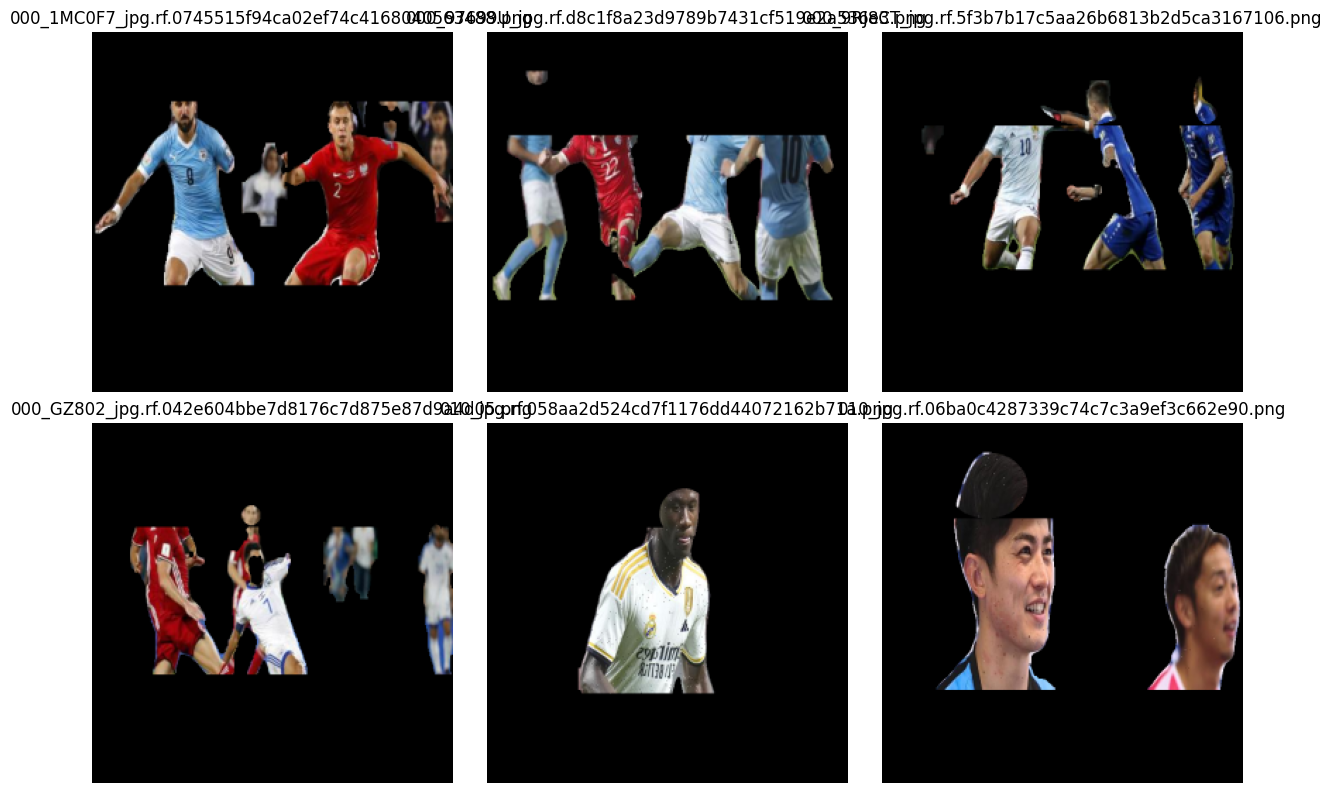

In [47]:
def verify_export_dimensions(output_dir: Path, expected_size: int = 256) -> Dict[str, Any]:
    checks = {}
    for sub in ["masked_rgb", "face_mask", "jersey_mask", "combined_mask"]:
        d = output_dir / sub
        if not d.exists():
            checks[sub] = {"exists": False, "count": 0, "all_ok": False}
            continue
        files = sorted([p for p in d.glob("*.png") if p.is_file()])
        all_ok = True
        for p in files[: min(50, len(files))]:
            with Image.open(p) as img:
                if img.size != (expected_size, expected_size):
                    all_ok = False
                    break
        checks[sub] = {"exists": True, "count": len(files), "all_ok": all_ok}
    return checks


def show_samples(output_dir: Path, n: int = 6) -> None:
    files = sorted((output_dir / "masked_rgb").glob("*.png"))[:n]
    if not files:
        print("No sample files found in outputs/masked_rgb")
        return

    cols = 3
    rows = (len(files) + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, p in enumerate(files, start=1):
        img = np.array(Image.open(p).convert("RGB"))
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(p.name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


dim_report = verify_export_dimensions(example_cfg.output_dir, expected_size=example_cfg.image_size)
print("Dimension report:")
print(json.dumps(dim_report, indent=2))

show_samples(example_cfg.output_dir, n=6)

## Final Preview: Did segmentation work?
This section renders side-by-side previews for a few samples so you can quickly verify face and jersey segmentation quality.

Columns shown:
1. Original image
2. Face mask
3. Jersey mask
4. Combined mask
5. Final masked RGB output

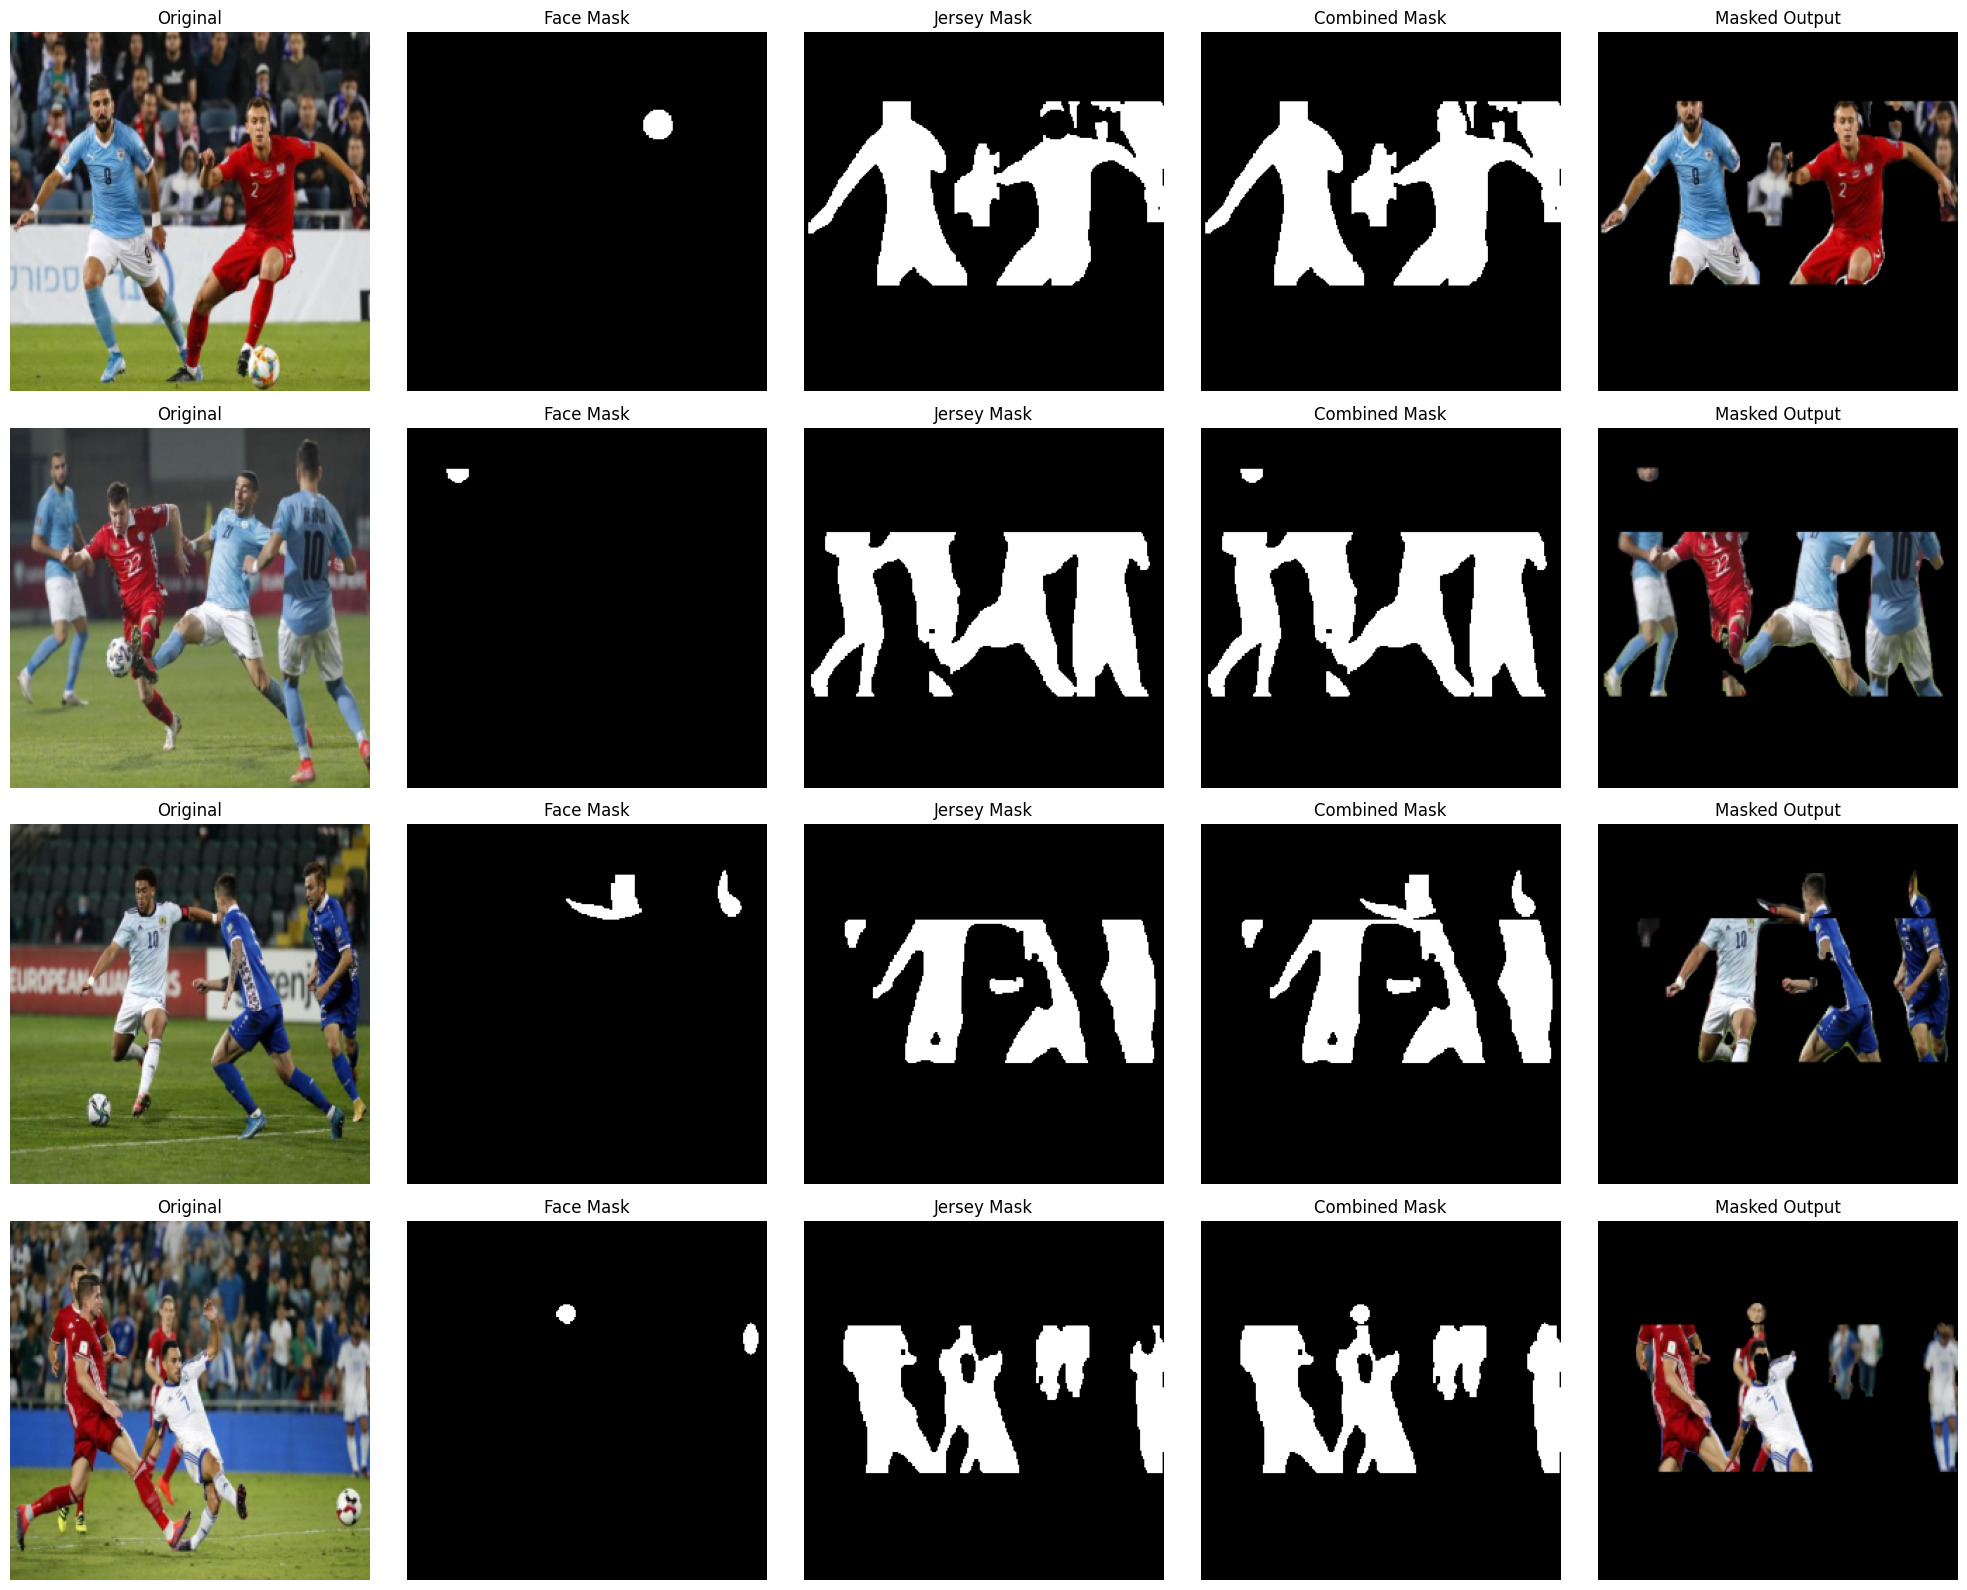

In [48]:
def preview_segmentation_results(output_dir: Path, dataset_dir: Path, n: int = 4) -> None:
    masked_dir = output_dir / "masked_rgb"
    face_dir = output_dir / "face_mask"
    jersey_dir = output_dir / "jersey_mask"
    combined_dir = output_dir / "combined_mask"

    if not masked_dir.exists():
        print(f"No outputs found at {masked_dir}. Run the pipeline cell first.")
        return

    stems = [p.stem for p in sorted(masked_dir.glob("*.png"))]
    if not stems:
        print("No masked outputs found. Run the pipeline cell first.")
        return

    stems = stems[: min(n, len(stems))]
    fig, axes = plt.subplots(len(stems), 5, figsize=(20, 4 * len(stems)))
    if len(stems) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, stem in enumerate(stems):
        original_path = None
        for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp"):
            candidate = dataset_dir / f"{stem}{ext}"
            if candidate.exists():
                original_path = candidate
                break

        if original_path is None:
            # fallback recursive lookup in case of nested paths
            matches = list(dataset_dir.rglob(f"{stem}.*"))
            original_path = matches[0] if matches else None

        if original_path and original_path.exists():
            original = np.array(Image.open(original_path).convert("RGB"))
            original = resize_with_padding_rgb(original, 256, (0, 0, 0))
        else:
            original = np.zeros((256, 256, 3), dtype=np.uint8)

        face = np.array(Image.open(face_dir / f"{stem}.png").convert("L")) if (face_dir / f"{stem}.png").exists() else np.zeros((256, 256), dtype=np.uint8)
        jersey = np.array(Image.open(jersey_dir / f"{stem}.png").convert("L")) if (jersey_dir / f"{stem}.png").exists() else np.zeros((256, 256), dtype=np.uint8)
        combined = np.array(Image.open(combined_dir / f"{stem}.png").convert("L")) if (combined_dir / f"{stem}.png").exists() else np.zeros((256, 256), dtype=np.uint8)
        masked = np.array(Image.open(masked_dir / f"{stem}.png").convert("RGB"))

        panels = [original, face, jersey, combined, masked]
        titles = ["Original", "Face Mask", "Jersey Mask", "Combined Mask", "Masked Output"]
        cmaps = [None, "gray", "gray", "gray", None]

        for col in range(5):
            axes[row, col].imshow(panels[col], cmap=cmaps[col])
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

        axes[row, 0].set_ylabel(stem, rotation=90, fontsize=9)

    plt.tight_layout()
    plt.show()


# Run this after pipeline execution
preview_segmentation_results(output_dir=example_cfg.output_dir, dataset_dir=example_cfg.dataset_dir, n=4)